In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import SIMPtools as st


In [2]:
# ---------------------------------------------------------------------------
# File Paths
# ---------------------------------------------------------------------------

# Directory with signal MC files
signal_dir = '/Users/mghrear/data/simp/signal'

# Directory for files with generator-level info
gen_dir = '/Users/mghrear/data/simp/gen'

# This notebooks fits a 7th order polynomial to A(ctau_rho) for each A' mass
# This is where the poly fit info will be saved
save_path = '/Users/mghrear/Desktop/2021/SIMP_signal/poly_fits.npz'

# ---------------------------------------------------------------------------
# Grid definition
# ---------------------------------------------------------------------------
MASSES_MEV = np.arange(50, 275, 25, dtype=float)
EPSILONS   = np.logspace(math.log10(1e-4), math.log10(1e-2), 150)




In [3]:

records = []

#loop over mass, epsilon grid
for i, mass in enumerate(MASSES_MEV):

    # Calculate dark sector masses and decay constant corresponding to this A' mass
    m_pi_D, m_V_D, f_pi_D = st.dark_masses(mass)

    # Calculate branching ratios for rho, and, phi
    # MG note: the final branching ratios are not actually mass dependent, this can probably be taken out of the loop 
    rho_w   = st.width_Ap_to_vector(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, 0.75)
    phi_w   = st.width_Ap_to_vector(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, 1.5)
    invis_w = st.width_Ap_to_invis(st.ALPHA_D, m_pi_D, m_V_D, mass)
    charg_w = st.width_Ap_to_charged(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass)
    total_w      = rho_w + phi_w + invis_w + charg_w
    rho_fraction = rho_w / total_w
    phi_fraction = phi_w / total_w

    # Load preselection-level event info
    events = st._events_cache(m_V_D, signal_dir)
    # Load generator-level event info
    df = pd.read_pickle(gen_dir+"/simp_"+str(int(m_V_D))+"_1000files.pkl")

    # True vertex position for preselection-level event
    z_ev = np.asarray(events["true_vd.vtx_z_"], dtype=np.float64)
    z_ev = z_ev + 1.1 # Account for target position
    # Truth Psum preselection-level event
    truth_psum_ev = np.sqrt(events["true_vd.pz_"]**2+events["true_vd.px_"]**2+events["true_vd.py_"]**2)
    gamma_ev = 1000.0 * truth_psum_ev / m_V_D # Compute gamma factor
    z_clipped = np.where(z_ev >= 0, z_ev, 0.0) # Ensure no negative z-vals

    # Vertex position for generator-level event
    z_ev_gen = np.array(df.vtx_z)
    z_ev_gen = z_ev_gen + 1.1 # Account for target position
    # Psum generator-level event
    psum_ev_gen = np.sqrt((np.array(df.ep_px)+np.array(df.em_px))**2 + (np.array(df.ep_py)+np.array(df.em_py))**2 + (np.array(df.ep_pz)+np.array(df.em_pz))**2)
    gamma_ev_gen = 1000.0 * psum_ev_gen / m_V_D # Compute gamma factor
    z_clipped_gen = np.where(z_ev_gen >= 0, z_ev_gen, 0.0)  # Ensure no negative z-vals


    for j, epsilon in enumerate(EPSILONS):

        # Get the decay lengths for rho and phi for this (epsilon, mass) pair
        rho_Gamma  = st.rate_2l(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, epsilon, 0.511, True)
        phi_Gamma  = st.rate_2l(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, epsilon, 0.511, False)
        rho_length = (1000 * st.HBAR_C * 10.0) / rho_Gamma
        phi_length = (1000 * st.HBAR_C * 10.0) / phi_Gamma

        # MG note: the visible branching ratios are not actually mass dependent, this can probably be taken out of the loop 
        tot_frac     = rho_fraction + phi_fraction
        rho_frac_vis = rho_fraction / tot_frac
        phi_frac_vis = phi_fraction / tot_frac

        # Calculate weights for preselection-level events
        # Weights include a contribution from rho and phi 
        p_accept = (
            rho_frac_vis * np.exp(-z_clipped / (gamma_ev * rho_length)) / (rho_length * gamma_ev)
            + phi_frac_vis * np.exp(-z_clipped / (gamma_ev * phi_length)) / (phi_length * gamma_ev)
            )

        # Calculate weights for generator-level events
        # Weights include a contribution from rho and phi 
        p_accept_gen = (
            rho_frac_vis * np.exp(-z_clipped_gen / (gamma_ev_gen * rho_length)) / (rho_length * gamma_ev_gen)
            + phi_frac_vis * np.exp(-z_clipped_gen / (gamma_ev_gen * phi_length)) / (phi_length * gamma_ev_gen)
            )

        # SIMP acceptance factor equivalent to Eq. 45 for A's
        # For the SIMP case, we also include a factor for the combined branching ratio 
        Ntilde_simp = (rho_fraction+phi_fraction) * (np.sum(p_accept)/(np.sum(p_accept_gen)))

        # Store data in dataframe
        records.append({'mass': mass, 'epsilon': epsilon, 'ctau_rho': rho_length, 'ctau_phi': phi_length,
                        'Ntilde_simp': Ntilde_simp, 'Ntilde_rad': st.Ntilde_rad(mass)})

df_results = pd.DataFrame(records)


# Diagnostic plots

## Plot Ntilde_simp vs epsilon
For the SIMP case, this includes a factor for the combined branching ratio 

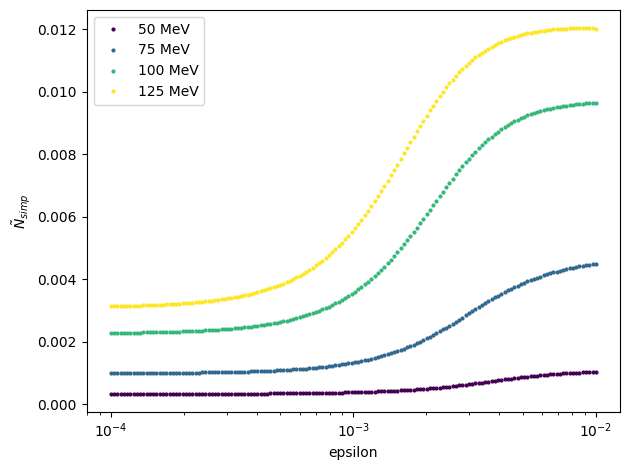

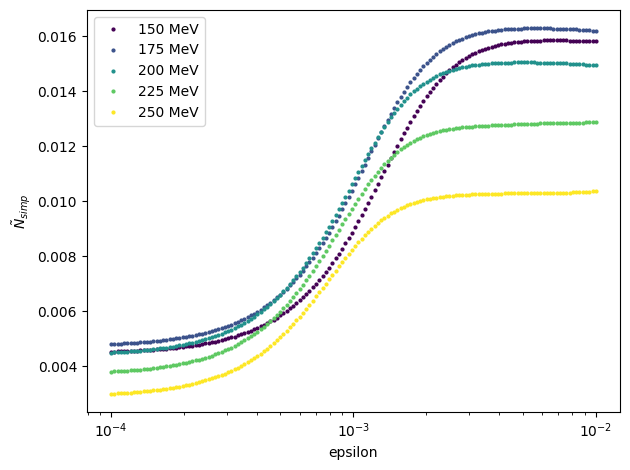

In [4]:
low_masses  = sorted(m for m in df_results['mass'].unique() if  50 <= m <= 125)
high_masses = sorted(m for m in df_results['mass'].unique() if 125 < m <= 250)

plt.figure()
colors_lo = plt.cm.viridis(np.linspace(0, 1, len(low_masses)))
for mass, color in zip(low_masses, colors_lo):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['epsilon'], sub['Ntilde_simp'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('$\\tilde{N}_{simp}$')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure()
colors_hi = plt.cm.viridis(np.linspace(0, 1, len(high_masses)))
for mass, color in zip(high_masses, colors_hi):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['epsilon'], sub['Ntilde_simp'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('$\\tilde{N}_{simp}$')
plt.legend()
plt.tight_layout()
plt.show()


## Plot A vs epsilon


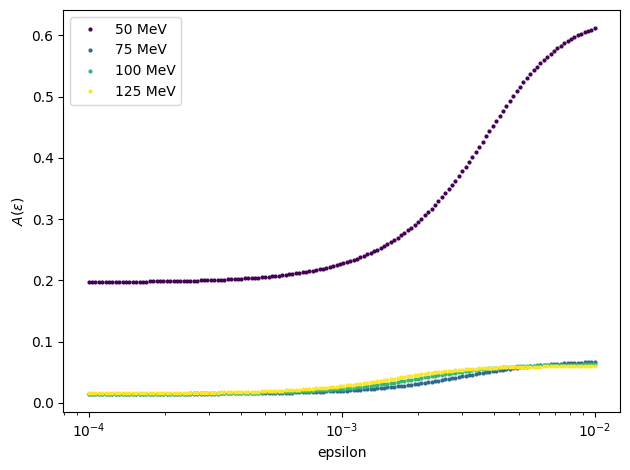

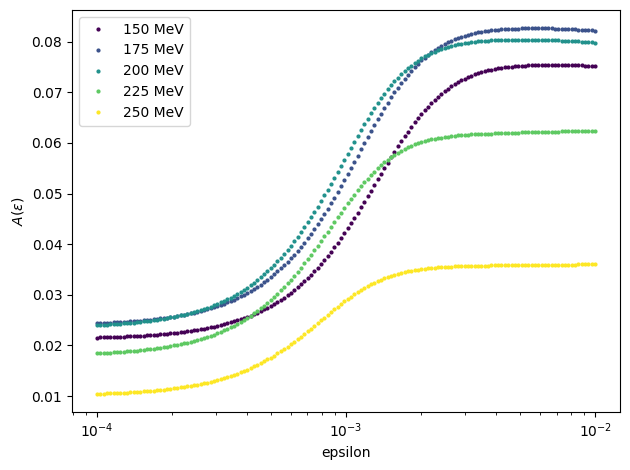

In [5]:
low_masses  = sorted(m for m in df_results['mass'].unique() if  50 <= m <= 125)
high_masses = sorted(m for m in df_results['mass'].unique() if 125 < m <= 250)

plt.figure()
colors_lo = plt.cm.viridis(np.linspace(0, 1, len(low_masses)))
for mass, color in zip(low_masses, colors_lo):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['epsilon'], sub['Ntilde_simp']/sub['Ntilde_rad'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('$A(\\varepsilon)$')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure()
colors_hi = plt.cm.viridis(np.linspace(0, 1, len(high_masses)))
for mass, color in zip(high_masses, colors_hi):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['epsilon'], sub['Ntilde_simp']/sub['Ntilde_rad'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('$A(\\varepsilon)$')
plt.legend()
plt.tight_layout()
plt.show()


## Plot A vs ctau_rho


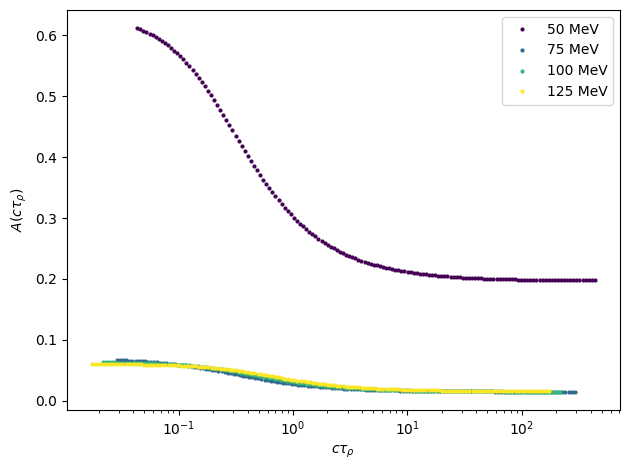

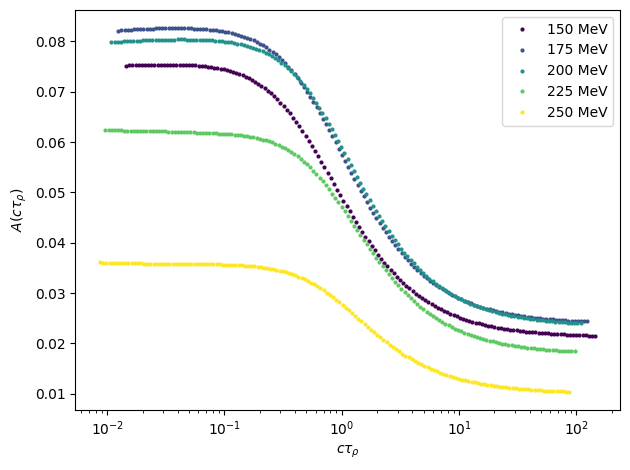

In [6]:
low_masses  = sorted(m for m in df_results['mass'].unique() if  50 <= m <= 125)
high_masses = sorted(m for m in df_results['mass'].unique() if 125 < m <= 250)

plt.figure()
colors_lo = plt.cm.viridis(np.linspace(0, 1, len(low_masses)))
for mass, color in zip(low_masses, colors_lo):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['ctau_rho'], sub['Ntilde_simp']/sub['Ntilde_rad'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('$c\\tau_{\\rho}$')
plt.ylabel('$A(c\\tau_{\\rho})$')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure()
colors_hi = plt.cm.viridis(np.linspace(0, 1, len(high_masses)))
for mass, color in zip(high_masses, colors_hi):
    sub = df_results[df_results['mass'] == mass].sort_values('epsilon')
    plt.plot(sub['ctau_rho'], sub['Ntilde_simp']/sub['Ntilde_rad'], color=color, marker='o', markersize=2, linestyle='none', label=f'{int(mass)} MeV')

plt.xscale('log')
plt.xlabel('$c\\tau_{\\rho}$')
plt.ylabel('$A(c\\tau_{\\rho})$')
plt.legend()
plt.tight_layout()
plt.show()


## Plot A vs A' mass at fixed epsilon

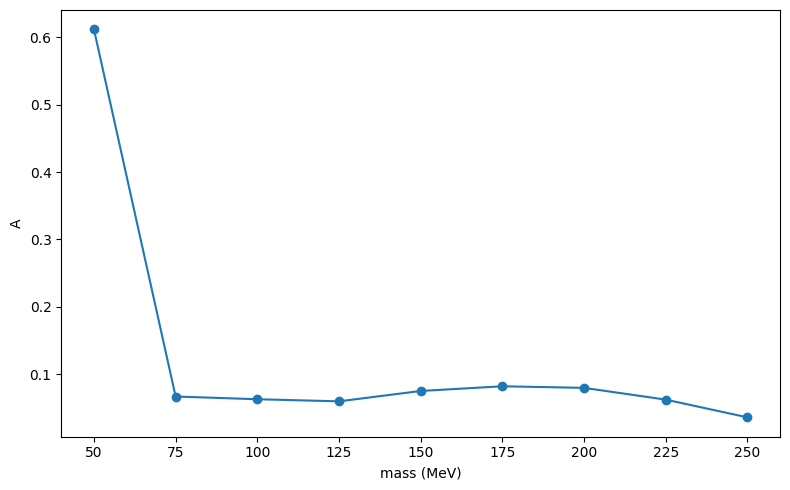

In [7]:
eps_target = 0.01
eps_val = df_results['epsilon'].iloc[(df_results['epsilon'] - eps_target).abs().argmin()]
sub = df_results[df_results['epsilon'] == eps_val].sort_values('mass')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub['mass'], sub['Ntilde_simp'] / sub['Ntilde_rad'], marker='o')
ax.set_xlabel('mass (MeV)')
ax.set_ylabel('A')
plt.tight_layout()
plt.show()


## Plot 7th order polynomial fit to A vs ctau_pho for each A' mass

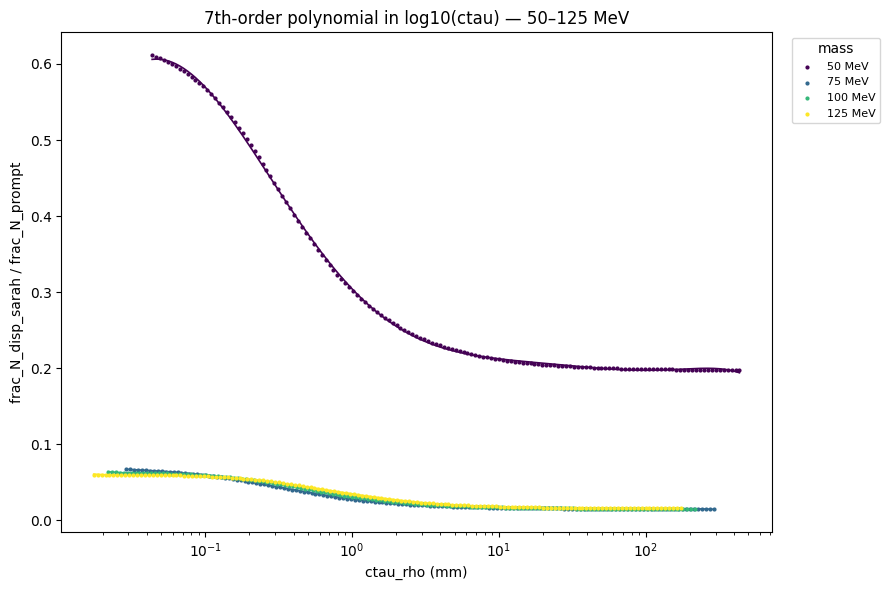

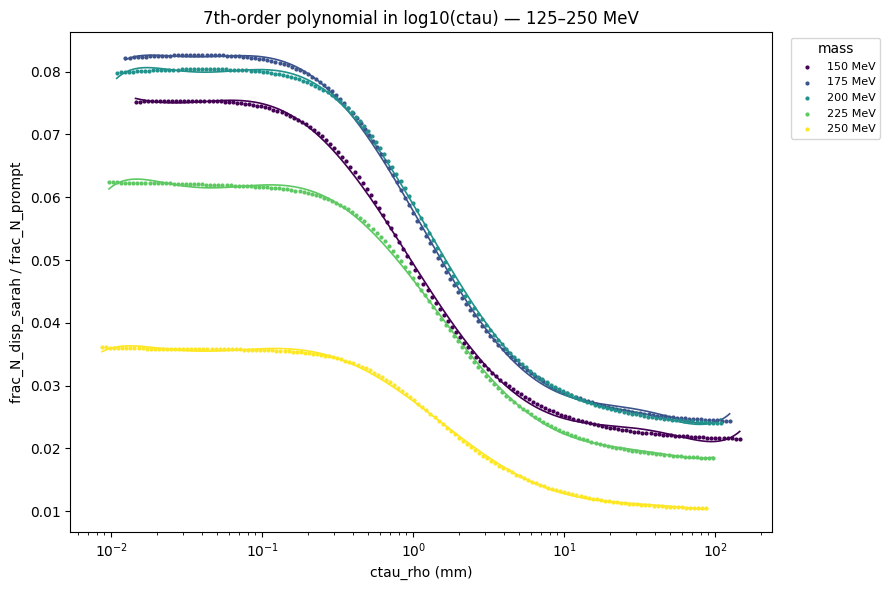

In [8]:
# Fit 7th-order polynomial in log10(ctau)

for masses, title_range in [(low_masses, '50–125 MeV'), (high_masses, '125–250 MeV')]:
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(masses)))
    for mass, color in zip(masses, colors):
        sub = df_results[df_results['mass'] == mass].sort_values('ctau_rho')
        x = sub['ctau_rho'].values
        y = (sub['Ntilde_simp'] / sub['Ntilde_rad']).values
        ax.scatter(x, y, color=color, label=f'{int(mass)} MeV', s=4, zorder=2)
        coeffs = np.polyfit(np.log10(x), y, 7)
        x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)
        ax.plot(x_fit, np.polyval(coeffs, np.log10(x_fit)), color=color, linewidth=1.2, zorder=1)
    ax.set_xscale('log')
    ax.set_xlabel('ctau_rho (mm)')
    ax.set_ylabel('frac_N_disp_sarah / frac_N_prompt')
    ax.set_title(f'7th-order polynomial in log10(ctau) — {title_range}')
    ax.legend(title='mass', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


# Save polynomial fits for later use

In [9]:
# Save polynomial fit parameters

all_masses = sorted(df_results['mass'].unique())
coeffs_list = []

for mass in all_masses:
    sub = df_results[df_results['mass'] == mass].sort_values('ctau_rho')
    x = sub['ctau_rho'].values
    y = (sub['Ntilde_simp'] / sub['Ntilde_rad']).values
    coeffs_list.append(np.polyfit(np.log10(x), y, 7))

coeffs_arr = np.array(coeffs_list)  # shape: (n_masses, 8)
masses_arr = np.array(all_masses)


np.savez(save_path, masses=masses_arr, coeffs=coeffs_arr)
print(f'Saved {len(all_masses)} fits to {save_path}')
print(f'masses shape: {masses_arr.shape}, coeffs shape: {coeffs_arr.shape}')


Saved 9 fits to /Users/mghrear/Desktop/2021/SIMP_signal/poly_fits.npz
masses shape: (9,), coeffs shape: (9, 8)


## An example of how to load and use the polynomial fits

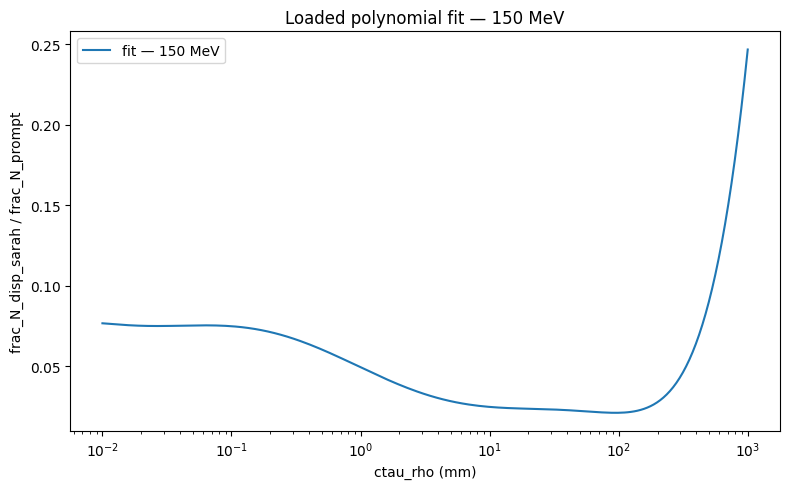

In [10]:
# Example: load fits and evaluate at arbitrary ctau for a given mass
data = np.load(save_path)
masses_loaded = data['masses']   # shape (n_masses,)
coeffs_loaded = data['coeffs']   # shape (n_masses, 8)

# Look up coefficients for a specific mass
query_mass = 150.0
idx = np.where(masses_loaded == query_mass)[0][0]
coeffs = coeffs_loaded[idx]

# Evaluate the fit at a range of ctau values
ctau_values = np.logspace(-2, 3, 200)
y_fit = np.polyval(coeffs, np.log10(ctau_values))

plt.figure(figsize=(8, 5))
plt.plot(ctau_values, y_fit, label=f'fit — {int(query_mass)} MeV')
plt.xscale('log')
plt.xlabel('ctau_rho (mm)')
plt.ylabel('frac_N_disp_sarah / frac_N_prompt')
plt.title(f'Loaded polynomial fit — {int(query_mass)} MeV')
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
np.polyval(coeffs, np.log10(0.01))

np.float64(0.07671874312526866)